In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import random
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training parameters
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [8]:
import os

print(os.listdir("/kaggle/input/datasets/ayazraza02"))

['brain-tumor-mri-dataset']


In [9]:
import os

DATASET_PATH = "/kaggle/input/datasets/ayazraza02/brain-tumor-mri-dataset"

print(os.listdir(DATASET_PATH))

['Training', 'Testing']


In [10]:
TRAIN_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Testing"

print("Training path:", TRAIN_PATH)
print("Testing path:", TEST_PATH)

Training path: /kaggle/input/datasets/ayazraza02/brain-tumor-mri-dataset/Training
Testing path: /kaggle/input/datasets/ayazraza02/brain-tumor-mri-dataset/Testing


In [11]:
print("Training classes:", os.listdir(TRAIN_PATH))
print("Testing classes:", os.listdir(TEST_PATH))

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [12]:
import os

classes = os.listdir(TRAIN_PATH)

for class_name in classes:
    folder = os.path.join(TRAIN_PATH, class_name)
    count = len(os.listdir(folder))
    print(f"{class_name}: {count} images")

pituitary: 1457 images
notumor: 1595 images
meningioma: 1339 images
glioma: 1321 images


In [13]:
print("\nTesting dataset:")

for class_name in os.listdir(TEST_PATH):
    folder = os.path.join(TEST_PATH, class_name)
    count = len(os.listdir(folder))
    print(f"{class_name}: {count} images")


Testing dataset:
pituitary: 300 images
notumor: 405 images
meningioma: 306 images
glioma: 300 images


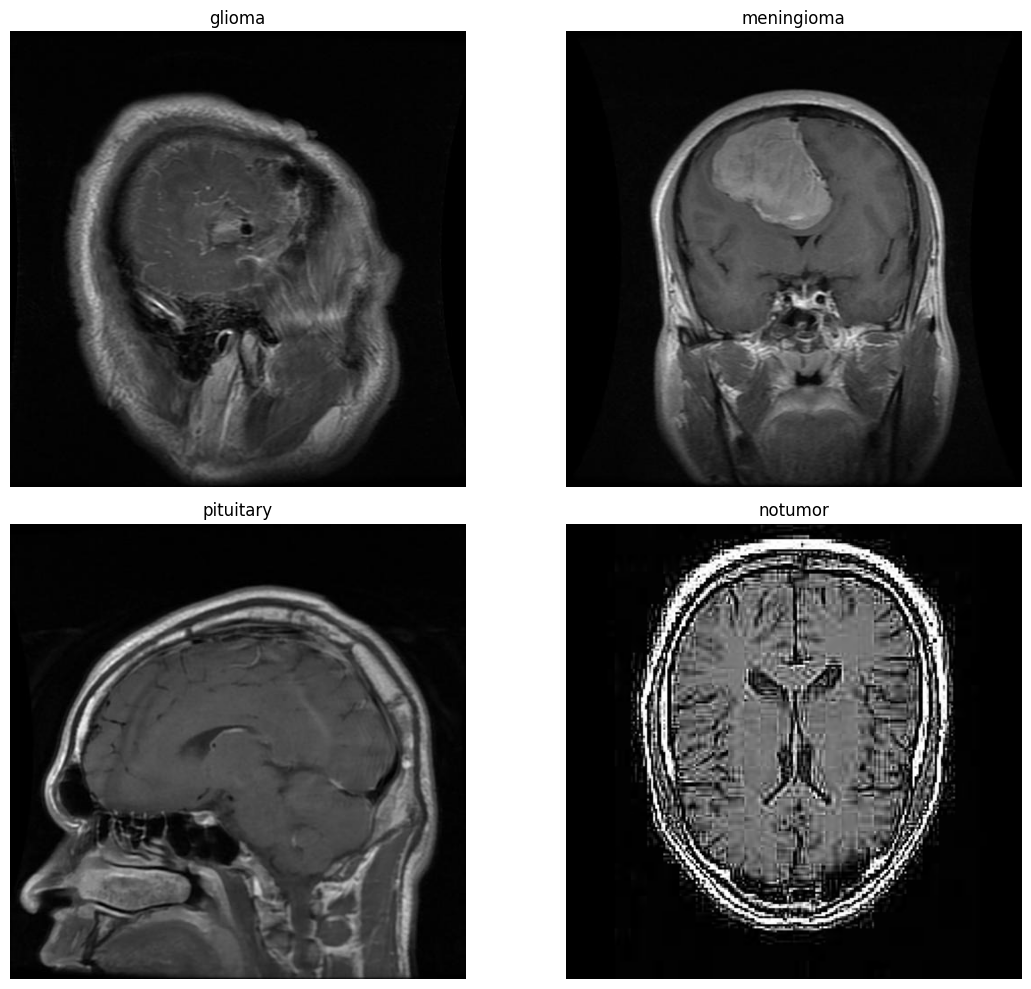

In [14]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.utils import load_img

classes = ['glioma', 'meningioma', 'pituitary', 'notumor']

plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):
    folder = os.path.join(TRAIN_PATH, class_name)
    
    # Take the first image
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = load_img(image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import os
import shutil

# Location for our new binary dataset
BINARY_PATH = "/kaggle/working/brain_tumor_binary"

# Create folders
for split in ["Training", "Testing"]:
    for category in ["tumor", "notumor"]:
        os.makedirs(
            os.path.join(BINARY_PATH, split, category),
            exist_ok=True
        )

print("Binary dataset folders created.")

Binary dataset folders created.


In [17]:
tumor_classes = ["glioma", "meningioma", "pituitary"]

for split in ["Training", "Testing"]:
    
    original_split_path = os.path.join(DATASET_PATH, split)
    binary_split_path = os.path.join(BINARY_PATH, split)
    
    # Copy glioma, meningioma and pituitary → tumor
    for class_name in tumor_classes:
        
        source_folder = os.path.join(original_split_path, class_name)
        destination_folder = os.path.join(binary_split_path, "tumor")
        
        for image_name in os.listdir(source_folder):
            
            source = os.path.join(source_folder, image_name)
            destination = os.path.join(
                destination_folder,
                f"{class_name}_{image_name}"
            )
            
            shutil.copy2(source, destination)
    
    # Copy notumor → notumor
    source_folder = os.path.join(original_split_path, "notumor")
    destination_folder = os.path.join(binary_split_path, "notumor")
    
    for image_name in os.listdir(source_folder):
        
        source = os.path.join(source_folder, image_name)
        destination = os.path.join(
            destination_folder,
            image_name
        )
        
        shutil.copy2(source, destination)

print("Images copied successfully!")

Images copied successfully!


In [18]:
for split in ["Training", "Testing"]:
    
    print(f"\n{split}")
    
    for category in ["tumor", "notumor"]:
        
        folder = os.path.join(BINARY_PATH, split, category)
        count = len(os.listdir(folder))
        
        print(f"{category}: {count} images")


Training
tumor: 4117 images
notumor: 1595 images

Testing
tumor: 906 images
notumor: 405 images


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 111

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [20]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(BINARY_PATH, "Training"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=SEED
)

Found 4570 images belonging to 2 classes.


In [21]:
validation_generator = train_datagen.flow_from_directory(
    os.path.join(BINARY_PATH, "Training"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=SEED
)

Found 1142 images belonging to 2 classes.


In [22]:
test_generator = test_datagen.flow_from_directory(
    os.path.join(BINARY_PATH, "Testing"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1311 images belonging to 2 classes.


In [23]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'notumor': 0, 'tumor': 1}


In [24]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

I0000 00:00:1788015343.077323      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788015343.080403      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully!


In [25]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

Trainable: False


In [26]:
from tensorflow.keras import models
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = models.Sequential([
    
    # Pretrained VGG16 feature extractor
    base_model,
    
    # Convert feature maps into a single feature vector
    GlobalAveragePooling2D(),
    
    # Our classification layers
    Dense(256, activation="relu"),
    
    Dropout(0.5),
    
    # Binary output: Tumor / No Tumor
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the class labels from the training generator
classes = train_generator.classes

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(
    zip(np.unique(classes), class_weights)
)

print("Class indices:")
print(train_generator.class_indices)

print("\nClass weights:")
print(class_weights)

Class indices:
{'notumor': 0, 'tumor': 1}

Class weights:
{np.int32(0): np.float64(1.7907523510971788), np.int32(1): np.float64(0.693685488767456)}


In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_vgg16_brain_tumor.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [30]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
  1/143 ━━━━━━━━━━━━━━━━━━━━ 34:30 15s/step - accuracy: 0.5625 - loss: 0.6661

I0000 00:00:1788015458.727552     195 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5728 - loss: 0.6835
Epoch 1: val_accuracy improved from None to 0.61121, saving model to /kaggle/working/best_vgg16_brain_tumor.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16_brain_tumor.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 102s 615ms/step - accuracy: 0.6720 - loss: 0.6081 - val_accuracy: 0.6112 - val_loss: 0.6204 - learning_rate: 1.0000e-04
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8390 - loss: 0.4531
Epoch 2: val_accuracy improved from 0.61121 to 0.64186, saving model to /kaggle/working/best_vgg16_brain_tumor.keras

Epoch 2: finished saving model to /kaggle/working/best_vgg16_brain_tumor.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 65s 455ms/step - accuracy: 0.8602 - loss: 0.4238 - val_accuracy: 0.6419 - val_loss: 0.5704 - learning_rate: 1.0000e-04
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8927 - loss: 0.3434
Epoch 3: val_accuracy improved from 0.64186 to 0.69177, sav

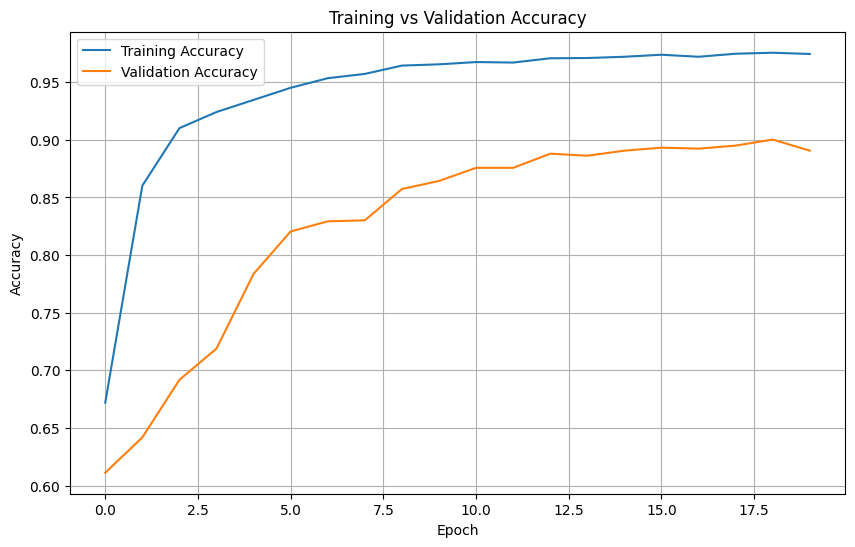

In [31]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

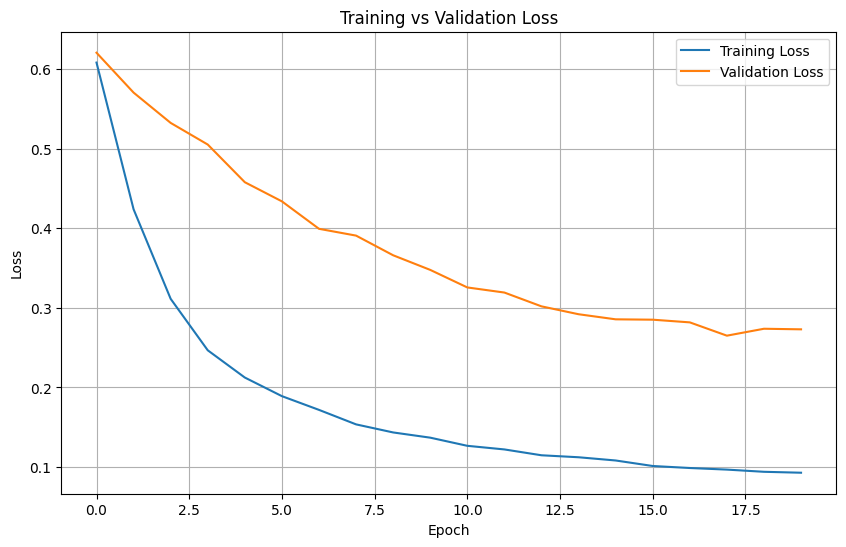

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 430ms/step - accuracy: 0.9275 - loss: 0.2066
Test Loss: 0.2066
Test Accuracy: 0.9275


In [34]:
import numpy as np

# Generate predictions for the complete test set
y_prob = model.predict(test_generator)

# Convert probabilities to class predictions
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Actual labels
y_true = test_generator.classes

print("Predictions generated!")
print("Number of test images:", len(y_true))

41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step
Predictions generated!
Number of test images: 1311


In [35]:
from sklearn.metrics import classification_report

# Class names
class_names = ["No Tumor", "Tumor"]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    No Tumor     0.8507    0.9284    0.8878       405
       Tumor     0.9666    0.9272    0.9465       906

    accuracy                         0.9275      1311
   macro avg     0.9087    0.9278    0.9172      1311
weighted avg     0.9308    0.9275    0.9284      1311



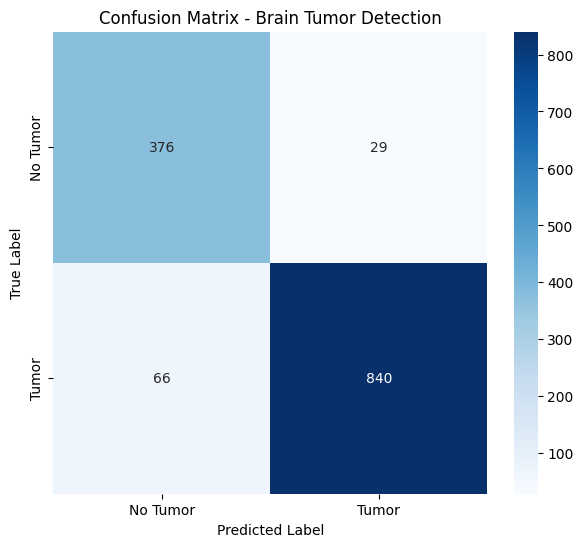

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Brain Tumor Detection")

plt.show()

In [37]:
# Unfreeze VGG16
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Check which layers are trainable
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [38]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [39]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9785 - loss: 0.0763
Epoch 1: val_accuracy improved from 0.90018 to 0.93695, saving model to /kaggle/working/best_vgg16_brain_tumor.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16_brain_tumor.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 77s 497ms/step - accuracy: 0.9779 - loss: 0.0787 - val_accuracy: 0.9370 - val_loss: 0.1603 - learning_rate: 1.0000e-05
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9869 - loss: 0.0477
Epoch 2: val_accuracy did not improve from 0.93695
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 459ms/step - accuracy: 0.9869 - loss: 0.0494 - val_accuracy: 0.9212 - val_loss: 0.2398 - learning_rate: 1.0000e-05
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9861 - loss: 0.0488
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.93695
143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 457ms/step - accuracy: 0.9888 

In [40]:
test_loss_ft, test_accuracy_ft = model.evaluate(
    test_generator,
    verbose=1
)

print(f"Fine-tuned Test Loss: {test_loss_ft:.4f}")
print(f"Fine-tuned Test Accuracy: {test_accuracy_ft:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.9710 - loss: 0.0912
Fine-tuned Test Loss: 0.0912
Fine-tuned Test Accuracy: 0.9710


In [41]:
# Reset test generator
test_generator.reset()

# Predict probabilities
y_prob_ft = model.predict(test_generator)

# Convert probabilities to binary predictions
y_pred_ft = (y_prob_ft >= 0.5).astype(int).ravel()

# True labels
y_true_ft = test_generator.classes

print("Predictions generated!")
print("Number of test images:", len(y_true_ft))

41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step
Predictions generated!
Number of test images: 1311


In [42]:
from sklearn.metrics import classification_report

class_names = ["No Tumor", "Tumor"]

print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    No Tumor     0.9318    0.9778    0.9542       405
       Tumor     0.9898    0.9680    0.9788       906

    accuracy                         0.9710      1311
   macro avg     0.9608    0.9729    0.9665      1311
weighted avg     0.9719    0.9710    0.9712      1311



In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

print(cm_ft)

[[396   9]
 [ 29 877]]


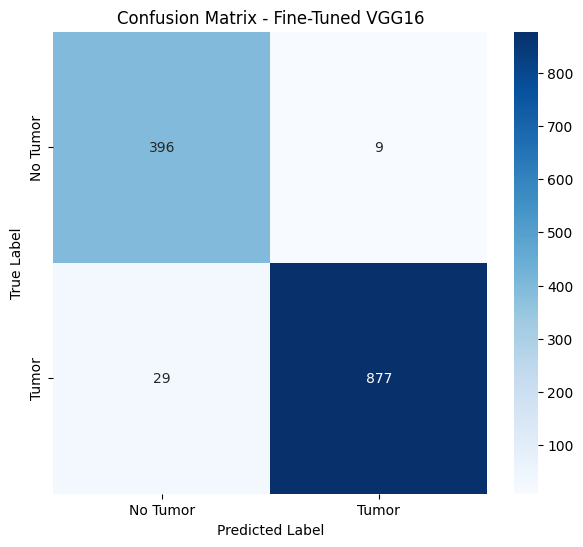

In [44]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned VGG16")

plt.show()

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_true_ft, y_prob_ft)

# Calculate AUC
auc_score = roc_auc_score(y_true_ft, y_prob_ft)

print(f"ROC-AUC: {auc_score:.4f}")

ROC-AUC: 0.9956


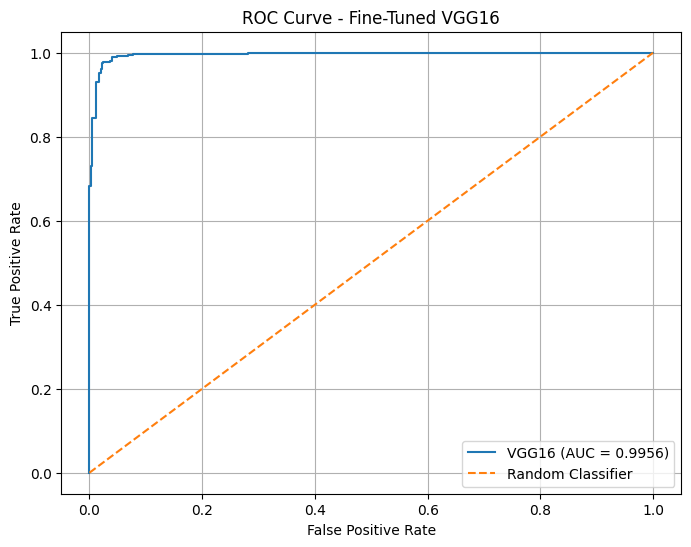

In [46]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"VGG16 (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fine-Tuned VGG16")
plt.legend()
plt.grid(True)

plt.show()

In [48]:
# Get the VGG16 model inside our complete model
vgg16_model = model.get_layer("vgg16")

# Get the last convolutional layer
last_conv_layer = vgg16_model.get_layer("block5_conv3")

print("VGG16 model:", vgg16_model.name)
print("Last convolutional layer:", last_conv_layer.name)

VGG16 model: vgg16
Last convolutional layer: block5_conv3


In [54]:
def make_gradcam_heatmap(img_array, model, vgg16_model, last_conv_layer):

    # Create a model that takes the original image
    # and returns the VGG16 feature maps + final prediction
    grad_model = tf.keras.models.Model(
        inputs=vgg16_model.input,
        outputs=[
            last_conv_layer.output,
            vgg16_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Get feature maps and VGG16 output
        conv_outputs, vgg_output = grad_model(img_array)

        # Pass VGG16 output through the remaining classifier
        x = vgg_output
        x = model.layers[1](x)   # GlobalAveragePooling2D
        x = model.layers[2](x)   # Dense
        x = model.layers[3](x)   # Dropout
        prediction = model.layers[4](x)  # Sigmoid

        tumor_probability = prediction[:, 0]

    # Gradients of tumor probability
    # with respect to the last convolutional feature maps
    grads = tape.gradient(
        tumor_probability,
        conv_outputs
    )

    # Average gradients over height and width
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps by gradients
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive activations
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

In [55]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    vgg16_model,
    last_conv_layer
)

prediction = model.predict(
    img_array,
    verbose=0
)[0][0]

print(f"Tumor probability: {prediction:.4f}")

if prediction >= 0.5:
    print("Prediction: TUMOR")
else:
    print("Prediction: NO TUMOR")

print("Heatmap shape:", heatmap.shape)

Tumor probability: 0.9974
Prediction: TUMOR
Heatmap shape: (14, 14)


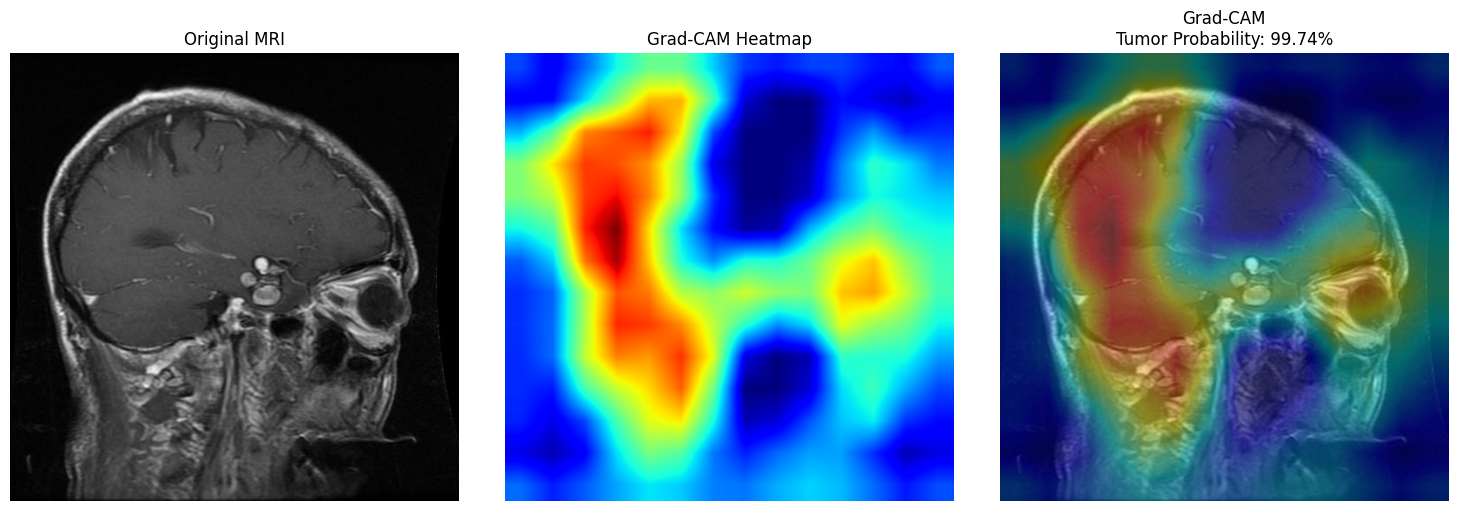

In [56]:
import cv2
import matplotlib.pyplot as plt

# Load the original MRI image
original_img = cv2.imread(image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original_img.shape[1], original_img.shape[0])
)

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR → RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay heatmap on MRI
superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM\nTumor Probability: {prediction:.2%}")
plt.axis("off")

plt.tight_layout()
plt.show()

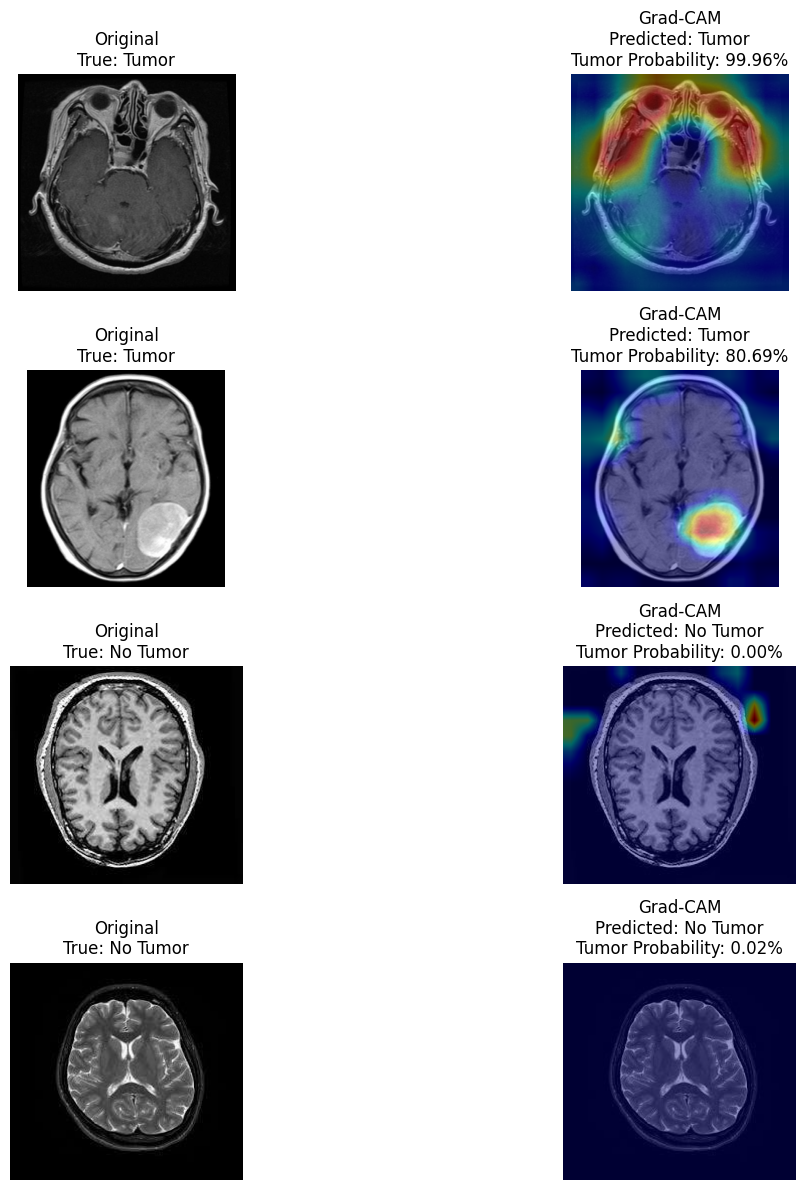

In [57]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

def show_gradcam(image_path, true_label):
    
    # Load image
    img = load_img(
        image_path,
        target_size=IMAGE_SIZE
    )
    
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    
    # Prediction
    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]
    
    predicted_label = "Tumor" if prediction >= 0.5 else "No Tumor"
    
    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        vgg16_model,
        last_conv_layer
    )
    
    # Original image
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(
        original_img,
        cv2.COLOR_BGR2RGB
    )
    
    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )
    
    # Convert to color heatmap
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )
    
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )
    
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )
    
    # Overlay
    overlay = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )
    
    return original_img, overlay, true_label, predicted_label, prediction


# Select images
tumor_folder = os.path.join(
    BINARY_PATH,
    "Testing",
    "tumor"
)

notumor_folder = os.path.join(
    BINARY_PATH,
    "Testing",
    "notumor"
)

tumor_images = random.sample(
    os.listdir(tumor_folder),
    2
)

notumor_images = random.sample(
    os.listdir(notumor_folder),
    2
)

selected_images = []

for image_name in tumor_images:
    selected_images.append(
        (
            os.path.join(tumor_folder, image_name),
            "Tumor"
        )
    )

for image_name in notumor_images:
    selected_images.append(
        (
            os.path.join(notumor_folder, image_name),
            "No Tumor"
        )
    )


# Display results
plt.figure(figsize=(14, 12))

for i, (image_path, true_label) in enumerate(selected_images):
    
    original, overlay, true_label, predicted_label, probability = show_gradcam(
        image_path,
        true_label
    )
    
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original)
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")
    
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM\n"
        f"Predicted: {predicted_label}\n"
        f"Tumor Probability: {probability:.2%}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
model.save(
    "/kaggle/working/brain_tumor_vgg16_final.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


In [59]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="/kaggle/working/brain_tumor_vgg16_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    show_dtype=True,
    expand_nested=True
)

print("Architecture saved successfully!")

Architecture saved successfully!


In [60]:
print("======================================")
print("   BRAIN TUMOR DETECTION - RESULTS")
print("======================================")

print(f"Test Accuracy : {test_accuracy_ft:.4f}")
print(f"Test Loss     : {test_loss_ft:.4f}")
print(f"ROC-AUC       : {auc_score:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=["No Tumor", "Tumor"],
        digits=4
    )
)

   BRAIN TUMOR DETECTION - RESULTS
Test Accuracy : 0.9710
Test Loss     : 0.0912
ROC-AUC       : 0.9956

Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.9318    0.9778    0.9542       405
       Tumor     0.9898    0.9680    0.9788       906

    accuracy                         0.9710      1311
   macro avg     0.9608    0.9729    0.9665      1311
weighted avg     0.9719    0.9710    0.9712      1311

